In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

mpl.rcParams.update({
    "font.family": "Arial", "axes.linewidth": 0.8,
    "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "xtick.major.size": 3.2, "ytick.major.size": 3.2,
    "xtick.direction": "out", "ytick.direction": "out",
})

c:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
cols = [
    "bgc", "type", "category", "start", "end", "length", "mag", "gtdb",
    "domain", "phylum", "class", "order", "family", "genus", "species",
]
df = pd.read_csv('../pre-calculated_data/bgc_region_len_gtdb.tsv', sep="\t", header=None, names=cols)
df["length_kb"] = df["length"] / 1000

In [4]:
def clean_taxon(x):
    if pd.isna(x):
        return "Unclassified"
    x = str(x)
    return x.split("__", 1)[1] if "__" in x else x

def broad_category(x):
    if pd.isna(x):
        return "Unclassified"
    x = str(x)
    if "." in x:
        return "Hybrid"
    mapping = {
        "nrps": "NRPS",
        "pks": "PKS",
        "ripp": "RiPP",
        "terpene": "Terpene",
        "saccharide": "Saccharide",
        "other": "Other",
    }
    return mapping.get(x.lower(), x)

In [5]:
df["broad_category"] = df["category"].map(broad_category)
df["phylum_clean"] = df["phylum"].map(clean_taxon)

plot_max_kb = 90
peak_min_kb = 38
peak_max_kb = 48
plot_df = df[df["length_kb"].between(0, plot_max_kb, inclusive="left")].copy()
second_peak_df = df[df["length_kb"].between(peak_min_kb, peak_max_kb, inclusive="left")].copy()


summary = df.groupby("broad_category")["length_kb"].agg(
    n_bgc="size", median_kb="median", min_kb="min", max_kb="max",
)
summary.round(2)

,n_bgc,median_kb,min_kb,max_kb
broad_category,,,,
Hybrid,1771,49.00,13.86,263.59
NRPS,6315,42.54,9.40,157.80
Other,5216,32.09,5.31,77.92
PKS,2954,41.06,12.28,112.70
RiPP,8814,20.77,5.22,61.32
Saccharide,37,41.91,21.94,62.38
Terpene,6527,21.54,9.22,46.29


In [6]:
category_order = ["NRPS", "PKS", "RiPP", "Terpene", "Saccharide", "Other", "Hybrid"]
category_order = [x for x in category_order if x in plot_df["broad_category"].unique()]
category_palette = {
    "NRPS": "#1b9e77",
    "PKS": "#d95f02",
    "RiPP": "#7570b3",
    "Terpene": "#e7298a",
    "Saccharide": "#66a61e",
    "Other": "#e6ab02",
    "Hybrid": "#a6761d",
}

phylum_palette = [
    "#8c510a", "#bf812d", "#dfc27d", "#f6e8c3",
    "#c7eae5", "#80cdc1", "#35978f", "#01665e",
]
other_color = "#666666"

In [7]:
def style_kde_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.spines["left"].set_zorder(10)
    ax.spines["bottom"].set_zorder(10)
    ax.tick_params(axis="both", labelsize=7.5, width=0.8, length=3.2, pad=2)
    ax.set_xlim(0, plot_max_kb)
    ax.set_xticks(np.arange(0, 91, 10))
    ax.set_yticks([0, 0.25])
    ax.set_ylabel("Density", fontsize=8.3, labelpad=7)
    ax.set_xlabel("")
    ax.axhline(0, color="black", lw=0.8, zorder=12)

def style_bar_axis(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(axis="both", labelsize=8, width=0.8, length=3.2, pad=2)

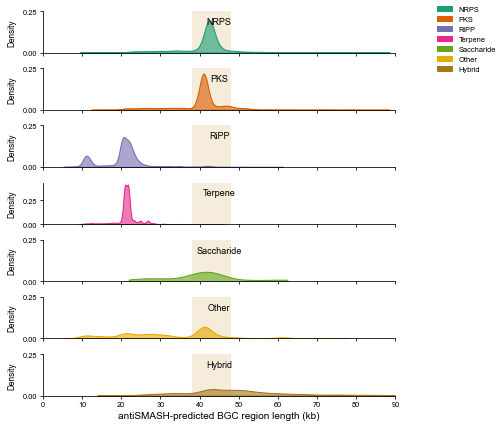

In [8]:
fig, axes = plt.subplots(len(category_order), 1, figsize=(7.2, 6.0))
for i, (ax, cat) in enumerate(zip(axes, category_order)):
    sub = plot_df.loc[plot_df["broad_category"].eq(cat)]
    ax.axvspan(peak_min_kb, peak_max_kb, color="#ead7b0", alpha=0.45, lw=0)
    sns.kdeplot(
        data=sub, x="length_kb", fill=True, alpha=0.62, linewidth=1.1,
        color=category_palette[cat], bw_adjust=0.75, cut=0,
        clip=(0, plot_max_kb), warn_singular=False, ax=ax, zorder=3,
    )
    style_kde_axis(ax)
    ax.text(0.5, 0.86, cat, transform=ax.transAxes,
            ha="center", va="top", fontsize=9)
    ax.tick_params(axis="x", labelbottom=(i == len(category_order) - 1))
axes[-1].set_xlabel("antiSMASH-predicted BGC region length (kb)", fontsize=10)
handles = [plt.Rectangle((0, 0), 1, 1, color=category_palette[c]) for c in category_order]
fig.legend(handles, category_order, loc="upper right", frameon=False, fontsize=7.5)
fig.subplots_adjust(left=0.12, right=0.80, top=0.98, bottom=0.09, hspace=0.38)
plt.show()

In [ ]:
top_n_stack_phyla = 8
top_stack_phyla = second_peak_df["phylum_clean"].value_counts().head(top_n_stack_phyla).index.tolist()
second_peak_df["phylum_stack"] = np.where(
    second_peak_df["phylum_clean"].isin(top_stack_phyla),
    second_peak_df["phylum_clean"],
    "Others",
)
phylum_order = top_stack_phyla + ["Others"]
phylum_colors = dict(zip(top_stack_phyla, phylum_palette))
phylum_colors["Others"] = other_color

second_peak_df["phylum_stack"].value_counts().rename_axis("Phylum").to_frame("n_bgc")

,n_bgc
Phylum,
Acidobacteriota,3641
Pseudomonadota,1885
Others,1163
Methylomirabilota,912
Desulfobacterota_B,597
Myxococcota,451
Bacteroidota,363
Planctomycetota,287
Gemmatimonadota,268


In [10]:
stack_counts = pd.crosstab(second_peak_df["broad_category"], second_peak_df["phylum_stack"])
stack_order = (
    stack_counts.sum(axis=1)
    .reindex(category_order)
    .dropna()
    .sort_values(ascending=False)
    .index
    .tolist()
)
stack_counts = stack_counts.reindex(index=stack_order, columns=phylum_order, fill_value=0)
stack_percent = stack_counts / len(second_peak_df) * 100

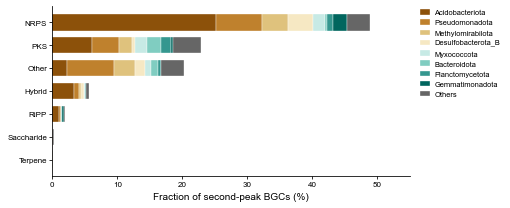

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 3.0))
left = np.zeros(len(stack_percent))
for phylum_name in phylum_order:
    values = stack_percent[phylum_name].to_numpy()
    ax.barh(stack_percent.index, values, left=left,
            color=phylum_colors[phylum_name], edgecolor="white",
            linewidth=0.35, height=0.72, label=phylum_name)
    left += values
style_bar_axis(ax)
ax.invert_yaxis()
ax.set_xlim(0, 55)
ax.set_xlabel("Fraction of second-peak BGCs (%)", fontsize=10, labelpad=5)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False,
          fontsize=7.5, borderaxespad=0, handlelength=1.4, handletextpad=0.5)
fig.tight_layout()
plt.show()